In [1]:
from sklearn.datasets import fetch_20newsgroups
categories = [
    "alt.atheism",
    "rec.autos",
    "comp.graphics",
    "sci.space",
    ]

data_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=(),
)


data_test = fetch_20newsgroups(
subset="test",
categories=categories,
shuffle=True,
random_state=42,
remove=(),
)

In [2]:
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
!pip install bertviz
from bertviz import head_view, model_view
# order of labels in `target_names ` can be different from `categories `
target_names = data_train.target_names

# split target in a training set and a test set
y_train, y_test = data_train.target, data_test.target

# Extracting features from the training data using a sparse vectorizer
vectorizer = TfidfVectorizer(
                    sublinear_tf=True,
                    max_df=0.5,
                    min_df=5,
                    stop_words="english"
                            )
X_train = vectorizer.fit_transform(data_train.data)

# Extracting features from the test data using the same vectorizer
X_test = vectorizer.transform(data_test.data)

feature_names = vectorizer.get_feature_names_out()

seq = X_test[:32,:]
b = seq.toarray()
att = b@b.T
att = att.reshape(1,1,32,32)
att = torch.tensor(att)
counts = [0,0,0,0]
tokens = []
for i in y_test[:32]:
    token = target_names[i] + ' ' + str(counts[i])
    tokens.append(token)
    counts[i]+=1
head_view((att,), tokens)


<IPython.core.display.Javascript object>

In [3]:
#(a) Explique o que essa visualização representa e interprete os resultados obtidos.
print('A visualização da figura "../reports/figures/4/attention.html" representa a matriz que correlaciona cada uma das 32 primeiras amostras do conjunto de teste às outras amostras. O valor de cada aresta é dado pelo produto' \
'interno entre as vetorizações tf-idf de cada par de notícias, ou seja, a similaridade entre dois textos dadas suas palavras ponderadas pelo inverso da frequência.')

A visualização da figura "../reports/figures/4/attention.html" representa a matriz que correlaciona cada uma das 32 primeiras amostras do conjunto de teste às outras amostras. O valor de cada aresta é dado pelo produtointerno entre as vetorizações tf-idf de cada par de notícias, ou seja, a similaridade entre dois textos dadas suas palavras ponderadas pelo inverso da frequência.


In [4]:
X_train = torch.tensor(X_train.toarray(), dtype=torch.float32).cuda()
X_train = (X_train-X_train.mean())/X_train.std()
y_train = torch.tensor(y_train, dtype=torch.float32).cuda()
X_test = torch.tensor(X_test.toarray(), dtype=torch.float32).cuda()
X_test = (X_test-X_test.mean())/X_test.std()
y_test = torch.tensor(y_test, dtype=torch.float32).cuda()


In [5]:

torch.manual_seed(0)
n_epochs = 5
lr = 1e-5
sequence_length = 32

def init_scale(fan_in):
  return (2/fan_in)**.5

D = X_train.shape[1]

A_K = torch.randn((D,D)).cuda()#*init_scale(D)
A_Q = torch.randn((D,D)).cuda()#*init_scale(D)

A_K_original = A_K.clone()
A_Q_original = A_Q.clone()

A_K.requires_grad = True
A_Q.requires_grad = True

optimizer = torch.optim.Adam([A_K, A_Q], lr = lr)
softmax = torch.nn.Softmax(dim=0)
cos = torch.nn.CosineSimilarity(dim=0)

losses = []
att_list = []
A_K_grad_sum = torch.zeros_like(A_K)  # stays on GPU
A_Q_grad_sum = torch.zeros_like(A_Q)  # stays on GPU
n_batches = 0

for epoch in range(n_epochs):
  permutation = torch.randperm(X_train.shape[0])
  for i in range(0,X_train.shape[0], sequence_length):
    optimizer.zero_grad()
    indices = permutation[i:i+sequence_length]
    if len(indices)!=sequence_length:
      continue

    seq_X, seq_Y = X_train[indices], y_train[indices]
    K = A_K@(seq_X.T)
    Q = A_Q@(seq_X.T)
    att = softmax((K.T@Q)/(D**(1/2)))
    truth = ((seq_Y-seq_Y.reshape(-1,1))==0).type(torch.float32)
    loss = -cos(att,truth).mean()
    loss.backward()
    if epoch==0:
      A_K_grad_sum += A_K.grad     # accumulate
      A_Q_grad_sum += A_Q.grad     # accumulate
      n_batches += 1
      att_list.append(att.detach().cpu().flatten().numpy())


    optimizer.step()
    losses.append(loss.detach().cpu())

A_K_grad_mean = (A_K_grad_sum / n_batches).detach().cpu().flatten().numpy()
A_Q_grad_mean = (A_Q_grad_sum / n_batches).detach().cpu().flatten().numpy()

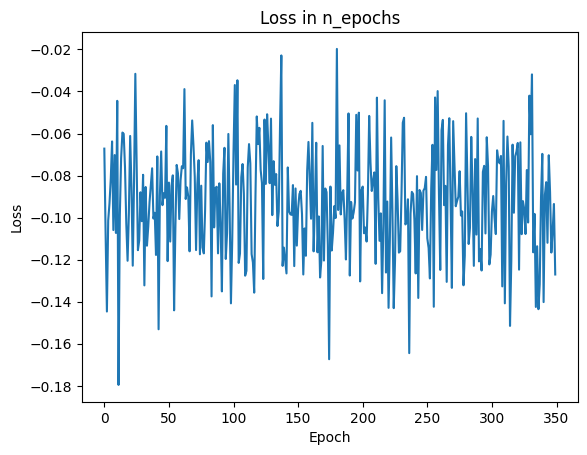

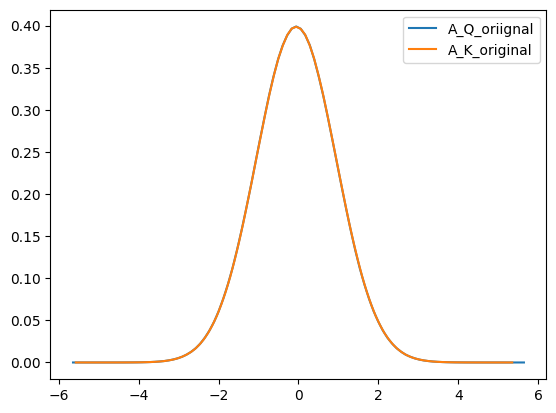

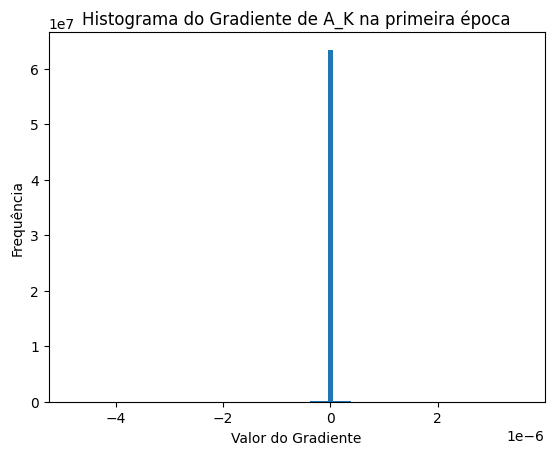

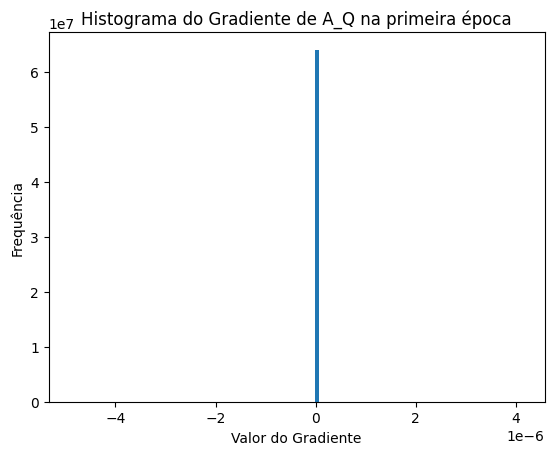

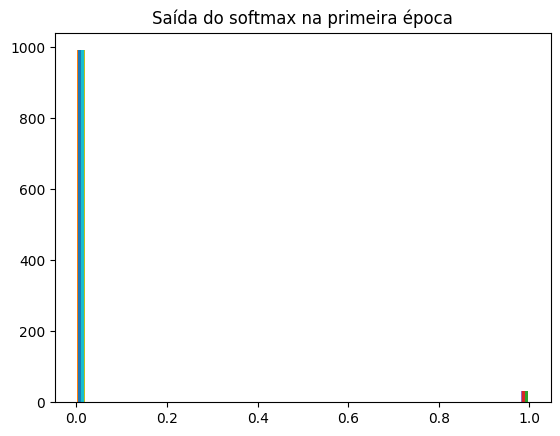

A inicialização incorreta da matriz de pesos é a causa do não aprendizado da rede. Como não normalizamos os pesos, sua variância era grande o suficiente para gerar valorescom alta magnitude que, ao passar pelo softmax, resulta valores próximos a 1 com um gradientes próximos a 0.


In [6]:

# (c) Note que a rede não está aprendendo. Explique qual é o problema e exponha evidências de que
# ele realmente está acontecendo.

import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('Loss in n_epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

hy, hx = torch.histogram(A_Q_original.detach().cpu(), density=True)
plt.plot(hx[:-1], hy)
hy, hx = torch.histogram(A_K_original.detach().cpu(), density=True)

plt.plot(hx[:-1], hy)
plt.legend(['A_Q_oriignal','A_K_original'])
plt.show()

plt.hist(A_K_grad_mean,bins=100)
plt.title('Histograma do Gradiente de A_K na primeira época')
plt.xlabel('Valor do Gradiente')
plt.ylabel('Frequência')
plt.show()

plt.hist(A_Q_grad_mean,bins=100)
plt.title('Histograma do Gradiente de A_Q na primeira época')
plt.xlabel('Valor do Gradiente')
plt.ylabel('Frequência')
plt.show()

plt.hist(att_list, bins=50)
plt.title('Saída do softmax na primeira época')
plt.show()

print('A inicialização incorreta da matriz de pesos é a causa do não aprendizado da rede. '\
'Como não normalizamos os pesos, sua variância era grande o suficiente para gerar valores'\
'com alta magnitude que, ao passar pelo softmax, resulta valores próximos a 1 com um '\
'gradientes próximos a 0.')


In [7]:
torch.manual_seed(0)
n_epochs = 5
lr = 1e-5
sequence_length = 32

def init_scale(fan_in):
  return (2/fan_in)**.5

D = X_train.shape[1]

A_K = torch.randn((D,D)).cuda()*init_scale(D)
A_Q = torch.randn((D,D)).cuda()*init_scale(D)

A_K_original = A_K.clone()
A_Q_original = A_Q.clone()

A_K.requires_grad = True
A_Q.requires_grad = True

optimizer = torch.optim.Adam([A_K, A_Q], lr = lr)
softmax = torch.nn.Softmax(dim=0)
cos = torch.nn.CosineSimilarity(dim=0)
att_list = []
losses = []
A_K_grad_sum = torch.zeros_like(A_K)  # stays on GPU
A_Q_grad_sum = torch.zeros_like(A_Q)  # stays on GPU
n_batches = 0

for epoch in range(n_epochs):
  permutation = torch.randperm(X_train.shape[0])
  for i in range(0,X_train.shape[0], sequence_length):
    optimizer.zero_grad()
    indices = permutation[i:i+sequence_length]
    if len(indices)!=sequence_length:
      continue

    seq_X, seq_Y = X_train[indices], y_train[indices]
    K = A_K@(seq_X.T)
    Q = A_Q@(seq_X.T)
    att = softmax((K.T@Q)/(D**(1/2)))
    truth = ((seq_Y-seq_Y.reshape(-1,1))==0).type(torch.float32)
    loss = -cos(att,truth).mean()
    loss.backward()
    if epoch==0:
      A_K_grad_sum += A_K.grad     # accumulate
      A_Q_grad_sum += A_Q.grad     # accumulate
      n_batches += 1
      att_list.append(att.detach().cpu().flatten().numpy())

    optimizer.step()
    losses.append(loss.detach().cpu())

A_K_grad_mean = (A_K_grad_sum / n_batches).detach().cpu().flatten().numpy()
A_Q_grad_mean = (A_Q_grad_sum / n_batches).detach().cpu().flatten().numpy()

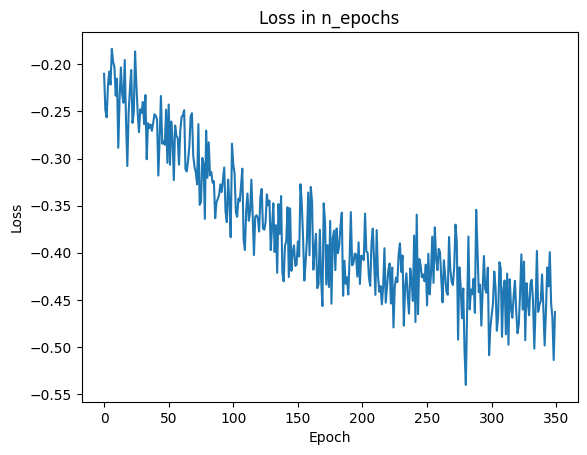

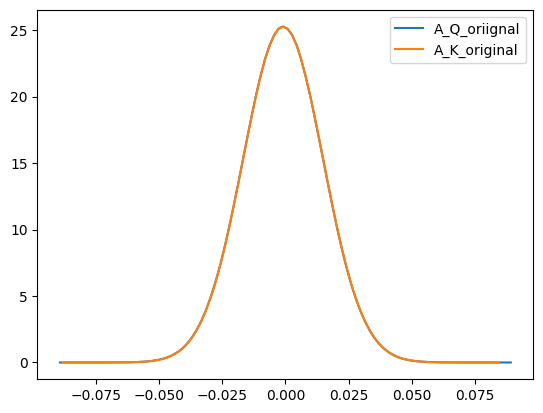

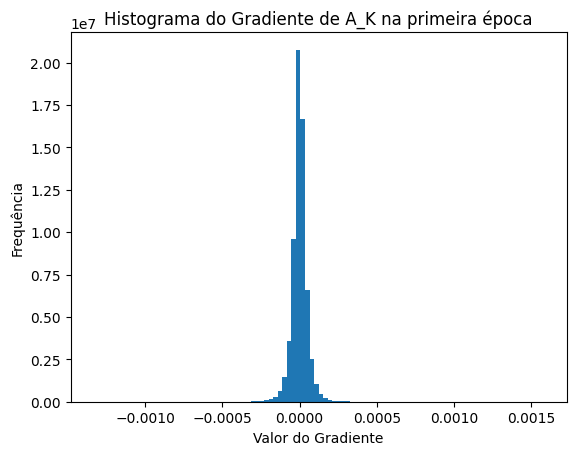

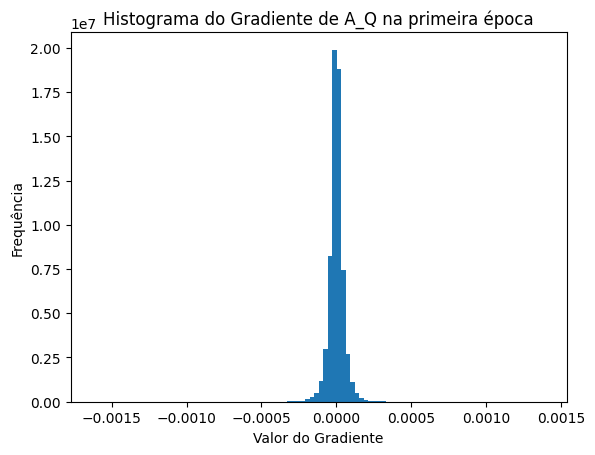

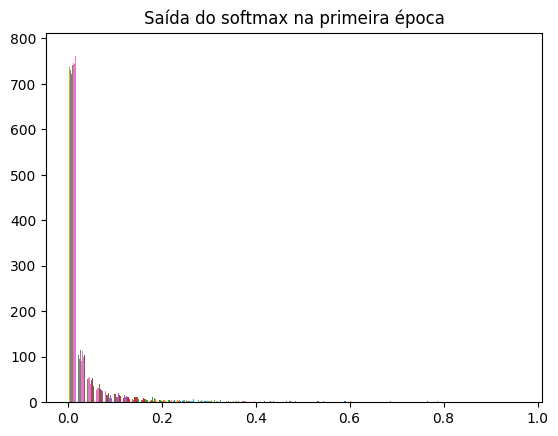

De fato adicionar um termo na inicialização dos parâmetros permitiu o aprendizado e subsequente redução da função perda. Isso ocorre pois o valor pelo qual multiplicamos
os pesos iniciais é (2/D)**.5, sendo D o tamanho da camada. Isso reduz a variância dos parâmetros e evita que valores muito grandes sejam passados ao softmax e tenham
seu gradiente próximo a zero.


In [13]:


import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('Loss in n_epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

hy, hx = torch.histogram(A_Q_original.detach().cpu(), density=True)
plt.plot(hx[:-1], hy)
hy, hx = torch.histogram(A_K_original.detach().cpu(), density=True)

plt.plot(hx[:-1], hy)
plt.legend(['A_Q_oriignal','A_K_original'])
plt.show()

plt.hist(A_K_grad_mean,bins=100)
plt.title('Histograma do Gradiente de A_K na primeira época')
plt.xlabel('Valor do Gradiente')
plt.ylabel('Frequência')
plt.show()

plt.hist(A_Q_grad_mean,bins=100)
plt.title('Histograma do Gradiente de A_Q na primeira época')
plt.xlabel('Valor do Gradiente')
plt.ylabel('Frequência')
plt.show()

plt.hist(att_list, bins=50)
plt.title('Saída do softmax na primeira época')
plt.show()


print('De fato adicionar um termo na inicialização dos parâmetros permitiu o aprendizado e subsequente redução da função perda. Isso ocorre pois o valor pelo qual multiplicamos')
print('os pesos iniciais é (2/D)**.5, sendo D o tamanho da camada. Isso reduz a variância dos parâmetros e evita que valores muito grandes sejam passados ao softmax e tenham')
print('seu gradiente próximo a zero.')


In [1]:
# (f ) Usando o comando head_view, visualize a similaridade par a par que a rede associa a sequência
# de notícias correspondente a X_test[:32], y_test[:32]. Compare com a visualização reali￾zada no item (a) e interprete o resultado.
att = (A_K.cpu().detach().numpy()@b.T ).T @ (A_Q.cpu().detach().numpy()@b.T )
att = att.reshape(1,1,32,32)
att = torch.tensor(att)
head_view((att,), tokens)

print('O resultado do presente head_view apresenta relações entre amostras da mesma classe mais fortes que o head_view do item (a), indicando o impacto do treinamento')
print('na definição da similaridade.')

NameError: name 'A_K' is not defined